In [88]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('~/repositories/go_figure/ClassicScience.mplstyle')

# plt.rcParams.update({
#     "font.family": "serif",
#     "text.usetex": True})

plt.rcParams.update({
    #"font.family"       : "serif",
    #"text.usetex"       : True,

    # No minor ticks => half as many tick marks immediately
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # … optional cosmetics
    "xtick.major.size"  : 4,     # length  of the remaining ticks
    "ytick.major.size"  : 4,
    "xtick.major.width" : 0.9,   # thickness of the ticks
    "ytick.major.width" : 0.9,
})


In [28]:
!which python

/usr/local/Caskroom/miniconda/base/envs/pyoperon/bin/python


/usr/local/Caskroom/miniconda/base/envs/pyoperon/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [2]:
import sys
# sys.path.append("/Users/lucas/repositories/degen_discovery/package_invSigma/")

import jax
import jax.numpy as jnp

a = 3.5  # average morning wait time
b = -1  # average difference afternoon wait time
sigma_a = 1  # std dev in intercepts
sigma_b = 0.5  # std dev in slopes
rho = -0.1  # correlation between intercepts and slopes

sigmas = jnp.array([sigma_a, sigma_b])  # standard deviations
Rho = jnp.array([[1, rho], [rho, 1]])  # correlation matrix

# now matrix multiply to get covariance matrix
Sigma = jnp.diag(sigmas) @ Rho @ jnp.diag(sigmas)


Sigma = jnp.eye(2)

In [3]:
def mu_x_from_y(y):
  x0 = y[0]
  x1 = y[1] - x0**2

  return jnp.array([x0, x1])

def mu_y_from_x(x):
  return jnp.array([x[0], x[1] + x[0]**2])

In [4]:
# vanilla rosenbrock
def rosen(x,y,a=1.,b=100.):
    return (a - x)**2. + b*(y - x**2)**2

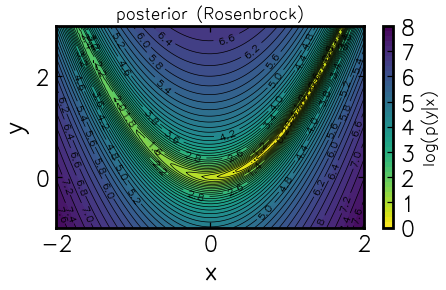

In [5]:
# toy version of Rosenbrock


# Sample data
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = rosen(X, Y)

Z = np.log(Z + 1.0)

# Create the filled contour plot
plt.figure(figsize=(1.5*3.41, 3.41))
contour = plt.contourf(X, Y, Z, levels=40, cmap='viridis_r')  # levels can be int or list
cbar = plt.colorbar(contour, label=r'$\log(p(y | x)$')  # Add a color bar
cbar.set_label(r'$\log(p(y | x)$', fontsize=15)
# Optional: add contour lines on top
lines = plt.contour(X, Y, Z, levels=40, colors='black', linewidths=0.5)
plt.clabel(lines, inline=True, fontsize=10)

# Labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('posterior (Rosenbrock)', fontsize=15)

# Show plot
plt.tight_layout()
plt.show()


# compare to posterior from multivariate normal setup


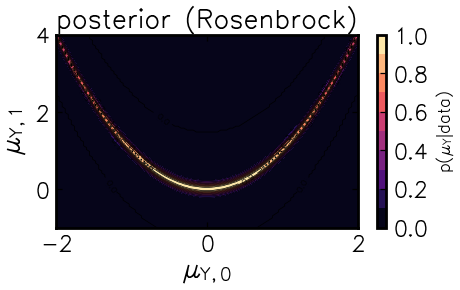

In [6]:
import numpy as np
import matplotlib.pyplot as plt

sigmas = np.array([1.0, 1.0/10])

sigmas = np.array([25., 1.0])

n_d = 100


def post(ν0, ν1, μ=0.0, sigmas=sigmas, n_d=n_d):
    sigmas = (sigmas / jnp.sqrt(n_d))**2
    return - 0.5 * (((ν0 - μ)**2 / sigmas[0]) + ((ν1 - ν0**2 - μ)**2 / sigmas[1]))


# Sample data
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 4, 100)
X, Y = np.meshgrid(x, y)
Z = (post)(X, Y) 
#Z -= Z.min()
Z = np.exp(Z)

#Z = np.log(Z)

# Create the filled contour plot
plt.figure(figsize=(1.5*3.41, 3.41))
contour = plt.contourf(X, Y, Z, levels=10, cmap='magma')  # levels can be int or list
cbar = plt.colorbar(contour, label=r'$p(\mu_Y | \rm data)$')  # Add a color bar

cbar.set_label(r'$p(\mu_Y | \rm data)$', fontsize=15)

# Optional: add contour lines on top
lines = plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5)
plt.clabel(lines, inline=True, fontsize=8)

# Labels and title
plt.xlabel(r'$\mu_{Y,0}$')
plt.ylabel(r'$\mu_{Y,1}$')
plt.title('posterior (Rosenbrock)')

# Show plot
plt.tight_layout()
plt.show()


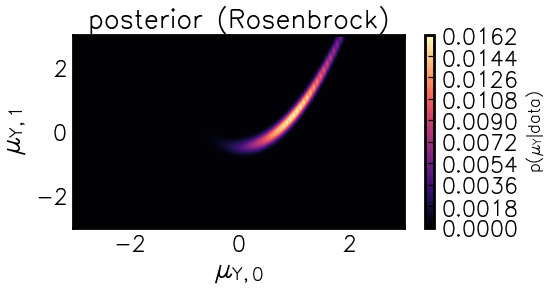

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import jax

sigmas = np.array([1.0, 1.0/10])

sigmas = np.array([2.0, 1.0])
sigmas = np.array([(4.0), 1.0])

# sigmas = np.array([1.0, 2.0])

n_d = 50


# def post(ν0, ν1, 
#          μ0=1.0,
#          μ1=0.5,
#          sigmas=sigmas, n_d=n_d):
#     sigmas = (sigmas / jnp.sqrt(n_d))**2
#     return - 0.5 * (((ν0 - μ0)**2 / sigmas[0]) + ((ν1 - ν0**2 - μ1)**2 / sigmas[1])) + np.log(np.sqrt(2*np.pi) * sigmas[0] * sigmas[1])


def post(ν0, ν1, 
         μ0=1.0,
         μ1=0.5,
         sigmas=sigmas, n_d=n_d):
    
    sigmas = (sigmas / jnp.sqrt(n_d))**2

    nu_target0 = μ0
    nu_target1 = - μ0**2 + μ1

    # transform so that the density is computed in degenerate space
    ν1 = ν1 - ν0**2
    
    return - 0.5 * ((((ν0 - nu_target0)**2 / sigmas[0]) + (ν1 - nu_target1)**2 / sigmas[1])) + np.log(np.sqrt(2*np.pi) * sigmas[0] * sigmas[1])




# Sample data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = (post)(X, Y) 
#Z -= Z.min()
Z = np.exp(Z)

#Z = np.log(Z + 1.0)

# Create the filled contour plot
plt.figure(figsize=(1.75*3.41, 3.41))
contour = plt.contourf(X, Y, Z, levels=60, cmap='magma')  # levels can be int or list
cbar = plt.colorbar(contour, label=r'$p(\mu_Y | \rm data)$')  # Add a color bar

cbar.set_label(r'$p(\mu_Y | \rm data)$', fontsize=15)



# Optional: add contour lines on top
#lines = plt.contour(X, Y, Z, levels=30, colors='black', linewidths=0.5)
#plt.clabel(lines, inline=True, fontsize=8)

# Labels and title
plt.xlabel(r'$\mu_{Y,0}$')
plt.ylabel(r'$\mu_{Y,1}$')
plt.title('posterior (Rosenbrock)')

# Show plot
plt.tight_layout()
plt.show()


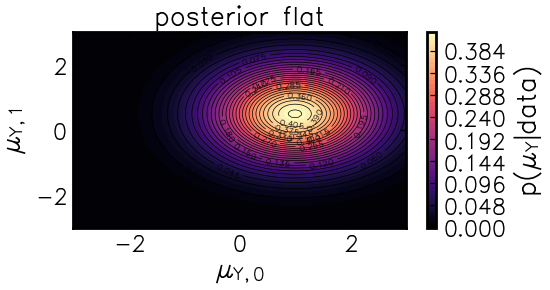

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import jax

sigmas = np.array([1.0, 1.0/10])

sigmas = np.array([2.0, 1.0])
sigmas = np.array([1.0, 1.0])

n_d = 50


def post_flat(ν0, ν1, 
         μ0=1.0,
         μ1=0.5,
         sigmas=sigmas, n_d=n_d):
    sigma = 1
    return - 0.5 * (((ν0 - μ0)**2 / sigma) + ((ν1 - μ1)**2 / sigma)) \
                    - np.log((2*np.pi)) - 0.5*np.log(np.sqrt(sigmas[0] * sigmas[1] / n_d))


# Sample data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = post_flat(X, Y) 
#Z -= Z.min()
Z = np.exp(Z)

#Z = np.log(Z + 1.0)

# Create the filled contour plot
plt.figure(figsize=(1.75*3.41, 3.41))
contour = plt.contourf(X, Y, Z, levels=60, cmap='magma')  # levels can be int or list
cbar = plt.colorbar(contour, label=r'$p(\mu_Y | \rm data)$')  # Add a color bar
cbar.set_label(r'$p(\mu_Y | \rm data)$')

# Optional: add contour lines on top
lines = plt.contour(X, Y, Z, levels=30, colors='black', linewidths=0.5)
plt.clabel(lines, inline=True, fontsize=8)

# Labels and title
plt.xlabel(r'$\mu_{Y,0}$')
plt.ylabel(r'$\mu_{Y,1}$')
plt.title('posterior flat')

# Show plot
plt.tight_layout()
plt.show()


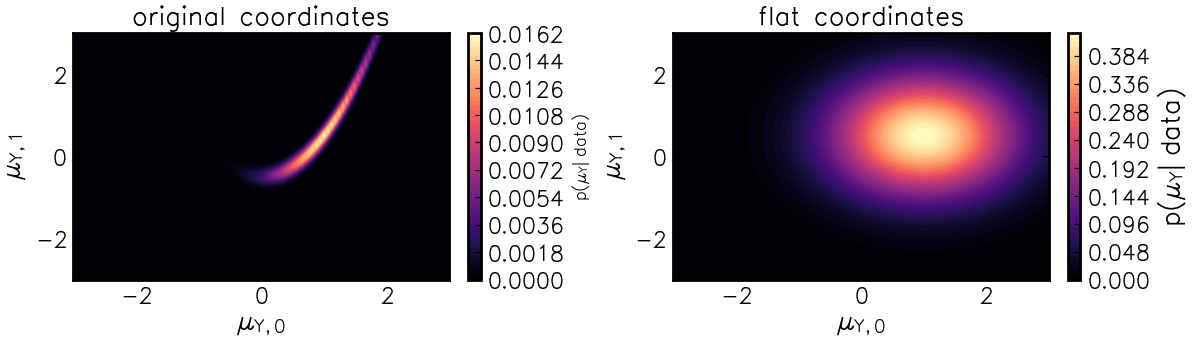

In [27]:
# two-panel plot


import numpy as np
import matplotlib.pyplot as plt
import jax  # kept since you had it, though it's not used below

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# ----------------------------
# Left panel: Rosenbrock posterior
# ----------------------------
sigmas_rosen = np.array([4.0, 1.0])
n_d = 50

def post(ν0, ν1,
         μ0=1.0,
         μ1=0.5,
         sigmas=sigmas_rosen, n_d=n_d):

    sigmas = (sigmas / np.sqrt(n_d))**2

    nu_target0 = μ0
    nu_target1 = -μ0**2 + μ1

    # transform so that the density is computed in degenerate space
    ν1 = ν1 - ν0**2

    return -0.5 * (
        ((ν0 - nu_target0)**2 / sigmas[0]) +
        ((ν1 - nu_target1)**2 / sigmas[1])
    ) + np.log(np.sqrt(2*np.pi) * sigmas[0] * sigmas[1])

Z1 = np.exp(post(X, Y))

# ----------------------------
# Right panel: flat posterior
# ----------------------------
sigmas_flat = np.array([1.0, 1.0])

def post_flat(ν0, ν1,
              μ0=1.0,
              μ1=0.5,
              sigmas=sigmas_flat, n_d=n_d):
    sigma = 1.0
    return (
        -0.5 * (((ν0 - μ0)**2 / sigma) + ((ν1 - μ1)**2 / sigma))
        - np.log(2*np.pi)
        - 0.5 * np.log(np.sqrt(sigmas[0] * sigmas[1] / n_d))
    )

Z2 = np.exp(post_flat(X, Y))

# ----------------------------
# Two-panel figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(2 * 1.75 * 3.41, 3.41), constrained_layout=True)

# Left plot
cf1 = axes[0].contourf(X, Y, Z1, levels=60, cmap='magma')
axes[0].set_xlabel(r'$\mu_{Y,0}$')
axes[0].set_ylabel(r'$\mu_{Y,1}$')
axes[0].set_title(r'original coordinates')
cbar1 = fig.colorbar(cf1, ax=axes[0])
cbar1.set_label(r'$p(\mu_Y |\ \rm data)$', fontsize=15)

# Right plot
cf2 = axes[1].contourf(X, Y, Z2, levels=60, cmap='magma')
# lines = axes[1].contour(X, Y, Z2, levels=30, colors='black', linewidths=0.5)
axes[1].clabel(lines, inline=True, fontsize=8)
axes[1].set_xlabel(r'$\mu_{Y,0}$')
axes[1].set_ylabel(r'$\mu_{Y,1}$')
axes[1].set_title(r'flat coordinates')
cbar2 = fig.colorbar(cf2, ax=axes[1])
cbar2.set_label(r'$p(\mu_Y |\ \rm data)$')

plt.show()

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/1624754329.py:78: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/1624754329.py:117: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_right.collections:


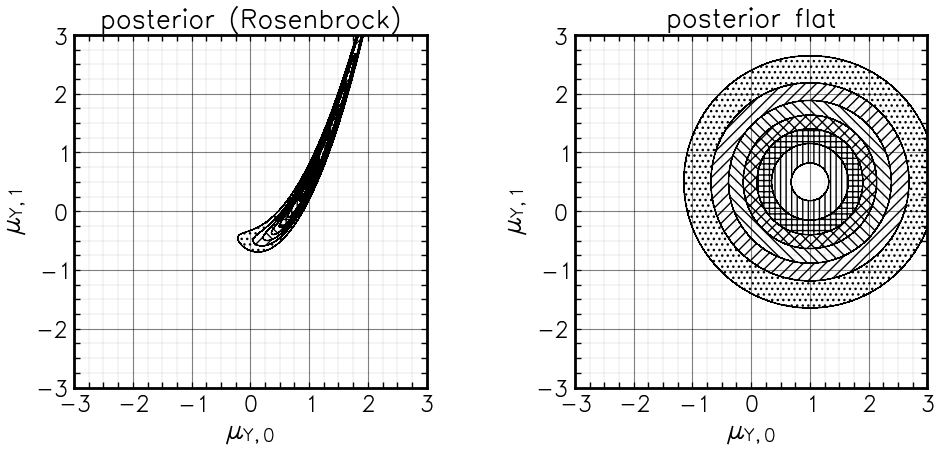

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([4.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.0,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):
    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transform so density is computed in degenerate space
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )
    return np.exp(logp)

# one density on the left
Z1 = post(X, Y, mu0=1.0, mu1=0.5)

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat,
              n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2 = post_flat(X, Y)

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

# hatch styles
hatches_left = ['...', '///', '\\\\\\', 'xxx', '+++', '|||']
hatches_right = ['...', '///', '\\\\\\', 'xxx', '+++', '|||']

# ----------------------------
# Left panel: one Rosenbrock contour set
# ----------------------------
ax = axes[0]
ax.set_facecolor('white')

levels_left = np.linspace(Z1.max() * 0.10, Z1.max() * 0.95, len(hatches_left) + 1)

cf_left = ax.contourf(
    X, Y, Z1,
    levels=levels_left,
    colors=['white'] * (len(levels_left) - 1),
    hatches=hatches_left
)

for coll in cf_left.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.4)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z1,
    levels=levels_left,
    colors='black',
    linewidths=1.0
)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title('posterior (Rosenbrock)')

# ----------------------------
# Right panel: flat posterior
# ----------------------------
ax = axes[1]
ax.set_facecolor('white')

levels_right = np.linspace(Z2.max() * 0.10, Z2.max() * 0.95, len(hatches_right) + 1)

cf_right = ax.contourf(
    X, Y, Z2,
    levels=levels_right,
    colors=['white'] * (len(levels_right) - 1),
    hatches=hatches_right
)

for coll in cf_right.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.4)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z2,
    levels=levels_right,
    colors='black',
    linewidths=1.0
)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title('posterior flat')

plt.show()

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/96539200.py:74: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/96539200.py:152: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_right.collections:


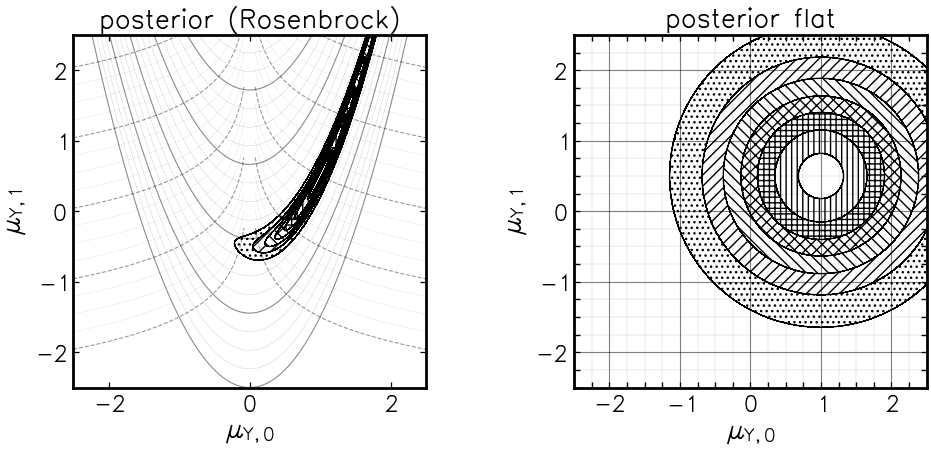

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([4.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.5,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):
    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transformed coordinate
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )
    return np.exp(logp)

Z1 = post(X, Y, mu0=1.0, mu1=0.5)

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat,
              n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2 = post_flat(X, Y)

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

hatches = ['...', '///', '\\\\\\', 'xxx', '+++', '|||']

# ----------------------------
# Left panel: hatched posterior + transformed coordinate grid
# ----------------------------
ax = axes[0]
ax.set_facecolor('white')

levels_left = np.linspace(Z1.max() * 0.10, Z1.max() * 0.95, len(hatches) + 1)

cf_left = ax.contourf(
    X, Y, Z1,
    levels=levels_left,
    colors=['white'] * (len(levels_left) - 1),
    hatches=hatches
)
for coll in cf_left.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.4)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z1,
    levels=levels_left,
    colors='black',
    linewidths=1.0
)

# coordinate family: nu1 = nu0^2 + c
# orthogonal family: nu1 = -0.5 log|nu0| + C
# make every 4th line "major", like a background grid
nu0_line = np.linspace(-3, 3, 1200)
c_values = np.linspace(-2.5, 2.51, 20)

for i, c in enumerate(c_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.45 if is_major else 0.18

    nu1_line = nu0_line**2 + c
    mask = (nu1_line >= -3) & (nu1_line <= 3)
    ax.plot(
        nu0_line[mask], nu1_line[mask],
        color='black', lw=lw, alpha=alpha
    )


nu0_pos = np.linspace(0.08, 3.0, 1200)
nu0_neg = np.linspace(-3.0, -0.08, 1200)
C_values = np.arange(-1.5, 2.51, 0.25)

for i, C in enumerate(C_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.40 if is_major else 0.16

    nu1_pos = -0.5 * np.log(np.abs(nu0_pos)) + C
    nu1_neg = -0.5 * np.log(np.abs(nu0_neg)) + C

    mask_pos = (nu1_pos >= -3) & (nu1_pos <= 3)
    mask_neg = (nu1_neg >= -3) & (nu1_neg <= 3)

    ax.plot(
        nu0_pos[mask_pos], nu1_pos[mask_pos],
        color='black', lw=lw, alpha=alpha, ls='--'
    )
    ax.plot(
        nu0_neg[mask_neg], nu1_neg[mask_neg],
        color='black', lw=lw, alpha=alpha, ls='--'
    )

xlim = 2.5

ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title('posterior (Rosenbrock)')

# ----------------------------
# Right panel: hatched flat posterior + ordinary grid
# ----------------------------
ax = axes[1]
ax.set_facecolor('white')

levels_right = np.linspace(Z2.max() * 0.10, Z2.max() * 0.95, len(hatches) + 1)

cf_right = ax.contourf(
    X, Y, Z2,
    levels=levels_right,
    colors=['white'] * (len(levels_right) - 1),
    hatches=hatches
)
for coll in cf_right.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.4)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z2,
    levels=levels_right,
    colors='black',
    linewidths=1.0
)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title('posterior flat')

plt.show()

In [83]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2273943079.py:99: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2273943079.py:110: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_B.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2273943079.py:203: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_right_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2273943079.py:214: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in

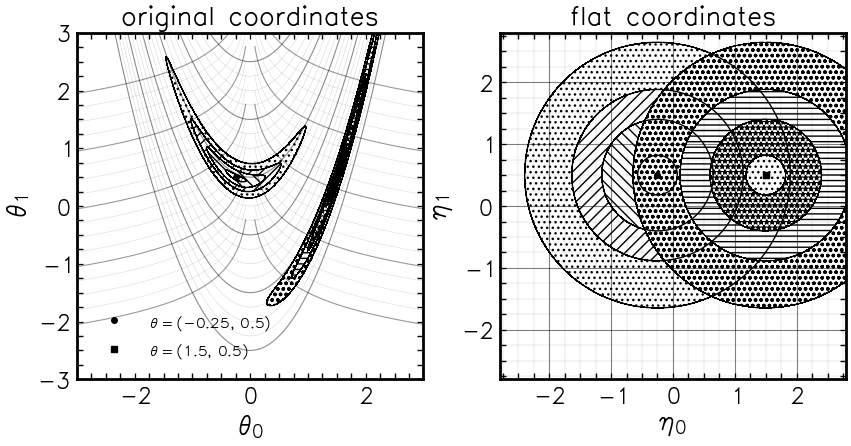

In [161]:
import numpy as np
import matplotlib.pyplot as plt

# Make hatch strokes a bit finer
plt.rcParams['hatch.linewidth'] = 1.0

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([4.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# Two mean locations, used in both panels
muA = (-0.25, 0.5)
muB = ( 1.5, 0.5)


# xlims for plot
xlim = 2.8
n_levels = 3

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.0,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):
    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transformed coordinate
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )
    return np.exp(logp)

Z1A = post(X, Y, mu0=muA[0], mu1=muA[1])
Z1B = post(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat,
              n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2A = post_flat(X, Y, mu0=muA[0], mu1=muA[1])
Z2B = post_flat(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=False)
# fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)

# fig, axes = plt.subplots(1, 2, figsize=(3.41 * 1.5, 3.41 * 0.75), constrained_layout=True)


# Distinct hatch styles for the two densities
hatches_A = ['...', '///', '\\\\\\', 'xxx', '+++', '|||']
hatches_B = ['ooo', '---', '***', '...', '///', '\\\\\\']


hatches_A = hatches_A[:n_levels]
hatches_B = hatches_B[:n_levels]

# ----------------------------
# Left panel: two Rosenbrock posteriors + transformed coordinate grid
# ----------------------------
ax = axes[0]
ax.set_facecolor('white')

levels_A_left = np.linspace(Z1A.max() * 0.10, Z1A.max() * 0.95, len(hatches_A) + 1)
levels_B_left = np.linspace(Z1B.max() * 0.10, Z1B.max() * 0.95, len(hatches_B) + 1)

cf_left_A = ax.contourf(
    X, Y, Z1A,
    levels=levels_A_left,
    colors=['white'] * (len(levels_A_left) - 1),
    hatches=hatches_A
)
for coll in cf_left_A.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

cf_left_B = ax.contourf(
    X, Y, Z1B,
    levels=levels_B_left,
    colors=['white'] * (len(levels_B_left) - 1),
    hatches=hatches_B
)
for coll in cf_left_B.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

# Contour lines to distinguish the two densities
ax.contour(
    X, Y, Z1A,
    levels=levels_A_left,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z1B,
    levels=levels_B_left,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)

# transformed coordinate family: nu1 = nu0^2 + c
# orthogonal family: nu1 = -0.5 log|nu0| + C
# every 4th line is "major"
nu0_line = np.linspace(-3, 3, 1200)
# c_values = np.linspace(-2.5, 2.51, 20)
c_values = np.arange(-2.5, 2.51, 0.25)

for i, c in enumerate(c_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.45 if is_major else 0.18

    nu1_line = nu0_line**2 + c
    mask = (nu1_line >= -3) & (nu1_line <= 3)
    ax.plot(
        nu0_line[mask], nu1_line[mask],
        color='black', lw=lw, alpha=alpha
    )

nu0_pos = np.linspace(0.08, 3.0, 1200)
nu0_neg = np.linspace(-3.0, -0.08, 1200)
C_values = np.arange(-1.5, 2.51, 0.25)

for i, C in enumerate(C_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.40 if is_major else 0.16

    nu1_pos = -0.5 * np.log(np.abs(nu0_pos)) + C
    nu1_neg = -0.5 * np.log(np.abs(nu0_neg)) + C

    mask_pos = (nu1_pos >= -3) & (nu1_pos <= 3)
    mask_neg = (nu1_neg >= -3) & (nu1_neg <= 3)

    ax.plot(
        nu0_pos[mask_pos], nu1_pos[mask_pos],
        color='black', lw=lw, alpha=alpha, ls='-'
    )
    ax.plot(
        nu0_neg[mask_neg], nu1_neg[mask_neg],
        color='black', lw=lw, alpha=alpha, ls='-'
    )

ax.plot(muA[0], muA[1], 'o', color='black', ms=4, label=rf'$\theta=({muA[0]},\,{muA[1]})$')
ax.plot(muB[0], muB[1], 's', color='black', ms=4, label=rf'$\theta=({muB[0]},\,{muB[1]})$')


ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title('original coordinates')
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.legend(frameon=False, fontsize=14, loc='lower left')

# ----------------------------
# Right panel: two flat posteriors at the same mean values + ordinary grid
# ----------------------------
ax = axes[1]
ax.set_facecolor('white')

levels_A_right = np.linspace(Z2A.max() * 0.10, Z2A.max() * 0.95, len(hatches_A) + 1)
levels_B_right = np.linspace(Z2B.max() * 0.10, Z2B.max() * 0.95, len(hatches_B) + 1)

cf_right_A = ax.contourf(
    X, Y, Z2A,
    levels=levels_A_right,
    colors=['white'] * (len(levels_A_right) - 1),
    hatches=hatches_A
)
for coll in cf_right_A.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

cf_right_B = ax.contourf(
    X, Y, Z2B,
    levels=levels_B_right,
    colors=['white'] * (len(levels_B_right) - 1),
     hatches=hatches_B
)
for coll in cf_right_B.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z2A,
    levels=levels_A_right,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z2B,
    levels=levels_B_right,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.plot(muA[0], muA[1], 'o', color='black', ms=4)
ax.plot(muB[0], muB[1], 's', color='black', ms=4)

ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\eta_0$')
ax.set_ylabel(r'$\eta_1$')
ax.set_title('flat coordinates')

# fig.text(
#     0.5, 0.53,
#     r'$\theta {f}{\mapsto} \eta$',
#     ha='center',
#     va='center',
#     fontsize=18
# )

plt.savefig('/Users/lucas/repositories/degeneracy_distillery/plots/rosenbrock_illustration.pdf', dpi=400)
plt.show()

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/692034963.py:208: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/692034963.py:219: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_B.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/692034963.py:315: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_right_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/692034963.py:326: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf

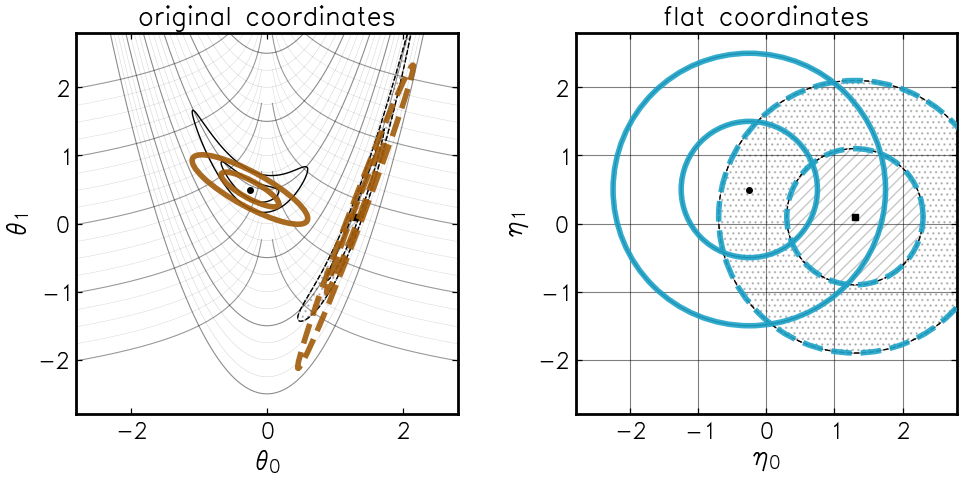

In [175]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Make hatch strokes a bit finer
plt.rcParams['hatch.linewidth'] = 1.0

# COLOUR STUFF
fishercolour = "#1ea3c8"

myorange = '#a05a0a'

fishercolour = myorange
flatcolour = "#1ea3c8"

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([3.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# Two mean locations, used in both panels
muA = (-0.25, 0.5)
muB = ( 1.5, 0.5)
muB = ( 1.3, 0.1)
xlim = 2.8

# Choose sigma convention for contour lines:
# "radius"      -> exp(-k^2/2)
# "probability" -> 2D enclosed-probability convention
sigma_mode = "radius"

# Fisher ellipse size (1, 2, or 3 are sensible)
ellipse_sigma = 2.0

num_sigmas = 2

# ----------------------------
# Helpers for sigma contour levels
# ----------------------------
# def sigma_ratios(mode="radius"):
#     if mode == "radius":
#         # 1σ, 2σ, 3σ in Mahalanobis-radius sense
#         return np.exp(-0.5 * np.array([3, 2, 1])**2)   # ascending order
#     elif mode == "probability":
#         # 1σ, 2σ, 3σ in 2D enclosed-probability sense
#         return np.array([0.0027, 0.0455, 0.3173])      # ascending order
#     else:
#         raise ValueError("mode must be 'radius' or 'probability'")

# def sigma_levels(Z, mode="radius"):
#     return Z.max() * sigma_ratios(mode)

# def sigma_fill_edges(Z, mode="radius"):
#     levels = sigma_levels(Z, mode)
#     # 4 filled regions: outside 3σ, 3σ-2σ, 2σ-1σ, inside 1σ
#     return np.array([0.0, levels[0], levels[1]])

#     # return np.array([0.0, levels[0], levels[1], levels[2], Z.max() * 1.000001])


from math import erf, sqrt

def _sigma_list(num_sigmas):
    if np.isscalar(num_sigmas):
        return np.arange(1, int(num_sigmas) + 1)
    return np.asarray(num_sigmas, dtype=float)

def sigma_ratios(mode="probability", num_sigmas=num_sigmas):
    k = _sigma_list(num_sigmas)

    if mode == "radius":
        # Z / Zmax = exp(-k^2 / 2)
        ratios = np.exp(-0.5 * k**2)

    elif mode == "probability":
        # 1D k-sigma enclosed probability:
        # p_k = erf(k / sqrt(2))
        # For a 2D Gaussian, matching enclosed-probability contour has
        # Z / Zmax = 1 - p_k
        ratios = np.array([1.0 - erf(kk / sqrt(2.0)) for kk in k])

    else:
        raise ValueError("mode must be 'radius' or 'probability'")

    return np.sort(ratios)  # ascending for contour/contourf

def sigma_levels(Z, mode="probability", num_sigmas=num_sigmas):
    return Z.max() * sigma_ratios(mode=mode, num_sigmas=num_sigmas)

def sigma_fill_edges(Z, mode="probability", num_sigmas=num_sigmas):
    levels = sigma_levels(Z, mode=mode, num_sigmas=num_sigmas)
    return np.concatenate(([0.0], levels, [Z.max() * 1.000001]))

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.0,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):
    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transformed coordinate
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )
    return np.exp(logp)

Z1A = post(X, Y, mu0=muA[0], mu1=muA[1])
Z1B = post(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat,
              n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2A = post_flat(X, Y, mu0=muA[0], mu1=muA[1])
Z2B = post_flat(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Local Fisher / Gaussian ellipse for left panel
# ----------------------------
def fisher_cov_rosen(mu0, mu1, sigmas=sigmas_rosen, n_d=n_d):
    s0, s1 = (sigmas / np.sqrt(n_d))**2

    # Hessian of -log p at the mode (mu0, mu1)
    H = np.array([
        [1.0 / s0 + 4.0 * mu0**2 / s1,  -2.0 * mu0 / s1],
        [-2.0 * mu0 / s1,                1.0 / s1]
    ])

    return np.linalg.inv(H)

def add_gaussian_ellipse(ax, center, cov, nsig=2.0, ls='-', lw=1.6, color='black', alpha=0.95):
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width = 2.0 * nsig * np.sqrt(vals[0])
    height = 2.0 * nsig * np.sqrt(vals[1])

    ell = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        linestyle=ls,
        alpha=alpha,
        zorder=10
    )
    ax.add_patch(ell)

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)

# 4 hatch bands: outside 3σ, 3σ-2σ, 2σ-1σ, inside 1σ
hatches_A = ['', 'ooo', '---', '\\\\\\']
hatches_B = ['', '...', '///', 'xxx']


# lighter hatch appearance
hatch_edge = (0, 0, 0, 0.22)

# ----------------------------
# Left panel: two Rosenbrock posteriors + transformed coordinate grid
# ----------------------------
ax = axes[0]
ax.set_facecolor('white')

fill_A_left = sigma_fill_edges(Z1A, sigma_mode)
fill_B_left = sigma_fill_edges(Z1B, sigma_mode)
line_A_left = sigma_levels(Z1A, sigma_mode)
line_B_left = sigma_levels(Z1B, sigma_mode)

cf_left_A = ax.contourf(
    X, Y, Z1A,
    levels=fill_A_left,
    colors=['white'] * (len(fill_A_left) - 1),
    hatches=hatches_A
)
for coll in cf_left_A.collections:
    coll.set_edgecolor(hatch_edge)
    coll.set_linewidth(0.20)
    coll.set_facecolor('white')

cf_left_B = ax.contourf(
    X, Y, Z1B,
    levels=fill_B_left,
    colors=['white'] * (len(fill_B_left) - 1),
    hatches=hatches_B
)
for coll in cf_left_B.collections:
    coll.set_edgecolor(hatch_edge)
    coll.set_linewidth(0.20)
    coll.set_facecolor('white')

# 1σ, 2σ, 3σ contour lines
ax.contour(
    X, Y, Z1A,
    levels=line_A_left,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z1B,
    levels=line_B_left,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)

# transformed coordinate family: nu1 = nu0^2 + c
nu0_line = np.linspace(-3, 3, 1200)
c_values = np.arange(-2.5, 2.51, 0.25)

for i, c in enumerate(c_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.45 if is_major else 0.18

    nu1_line = nu0_line**2 + c
    mask = (nu1_line >= -3) & (nu1_line <= 3)
    ax.plot(
        nu0_line[mask], nu1_line[mask],
        color='black', lw=lw, alpha=alpha
    )

# orthogonal family: nu1 = -0.5 log|nu0| + C
nu0_pos = np.linspace(0.08, 3.0, 1200)
nu0_neg = np.linspace(-3.0, -0.08, 1200)
C_values = np.arange(-1.5, 2.51, 0.25)

for i, C in enumerate(C_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.40 if is_major else 0.16

    nu1_pos = -0.5 * np.log(np.abs(nu0_pos)) + C
    nu1_neg = -0.5 * np.log(np.abs(nu0_neg)) + C

    mask_pos = (nu1_pos >= -3) & (nu1_pos <= 3)
    mask_neg = (nu1_neg >= -3) & (nu1_neg <= 3)

    ax.plot(nu0_pos[mask_pos], nu1_pos[mask_pos], color='black', lw=lw, alpha=alpha, ls='-')
    ax.plot(nu0_neg[mask_neg], nu1_neg[mask_neg], color='black', lw=lw, alpha=alpha, ls='-')

# Fisher / Gaussian approximation ellipses
covA = fisher_cov_rosen(muA[0], muA[1])
covB = fisher_cov_rosen(muB[0], muB[1])

add_gaussian_ellipse(ax, muA, covA, nsig=1, ls='-',  lw=4.0, color=fishercolour, alpha=0.9)
add_gaussian_ellipse(ax, muA, covA, nsig=2, ls='-',  lw=4.0, color=fishercolour, alpha=0.9)


add_gaussian_ellipse(ax, muB, covB, nsig=1, ls='--', lw=4.0, color=fishercolour, alpha=0.9)
add_gaussian_ellipse(ax, muB, covB, nsig=2, ls='--', lw=4.0, color=fishercolour, alpha=0.9)


ax.plot(muA[0], muA[1], 'o', color='black', ms=4, label=rf'$(\mu_0,\mu_1)=({muA[0]},\,{muA[1]})$')
ax.plot(muB[0], muB[1], 's', color='black', ms=4, label=rf'$(\mu_0,\mu_1)=({muB[0]},\,{muB[1]})$')

ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(f'original coordinates')
# ax.legend(frameon=False, fontsize=8, loc='upper left')

# ----------------------------
# Right panel: two flat posteriors at same mean values + ordinary grid
# ----------------------------
ax = axes[1]
ax.set_facecolor('white')

fill_A_right = sigma_fill_edges(Z2A, sigma_mode)
fill_B_right = sigma_fill_edges(Z2B, sigma_mode)
line_A_right = sigma_levels(Z2A, sigma_mode)
line_B_right = sigma_levels(Z2B, sigma_mode)

cf_right_A = ax.contourf(
    X, Y, Z2A,
    levels=fill_A_right,
    colors=['white'] * (len(fill_A_right) - 1),
    hatches=hatches_A
)
for coll in cf_right_A.collections:
    coll.set_edgecolor(hatch_edge)
    coll.set_linewidth(0.20)
    coll.set_facecolor('white')

cf_right_B = ax.contourf(
    X, Y, Z2B,
    levels=fill_B_right,
    colors=['white'] * (len(fill_B_right) - 1),
    hatches=hatches_B
)
for coll in cf_right_B.collections:
    coll.set_edgecolor(hatch_edge)
    coll.set_linewidth(0.20)
    coll.set_facecolor('white')

ax.contour(
    X, Y, Z2A,
    levels=line_A_right,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z2B,
    levels=line_B_right,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)


add_gaussian_ellipse(ax, muB, np.eye(2), nsig=1, ls='--', lw=4.0, color=flatcolour, alpha=0.9)
add_gaussian_ellipse(ax, muB, np.eye(2), nsig=2, ls='--', lw=4.0, color=flatcolour, alpha=0.9)


add_gaussian_ellipse(ax, muA, np.eye(2), nsig=1, ls='-', lw=4.0, color=flatcolour, alpha=0.9)
add_gaussian_ellipse(ax, muA, np.eye(2), nsig=2, ls='-', lw=4.0, color=flatcolour, alpha=0.9)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
# ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
# ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.plot(muA[0], muA[1], 'o', color='black', ms=4)
ax.plot(muB[0], muB[1], 's', color='black', ms=4)

ax.set_xlim(-xlim, xlim)
ax.set_ylim(-xlim, xlim)
ax.set_aspect('equal')
ax.set_xlabel(r'$\eta_0$')
ax.set_ylabel(r'$\eta_1$')
ax.set_title(f'flat coordinates')

# Mapping text between panels
# fig.text(
#     0.5, 0.53,
#     r'$\theta \overset{f}{\mapsto} \eta$',
#     ha='center',
#     va='center',
#     fontsize=18
# )
plt.savefig('/Users/lucas/repositories/degeneracy_distillery/plots/fishnets-flattening-bits.pdf', transparent=True, dpi=400)

plt.show()

In [173]:
covA + np.random.normal(size=(2,2))

array([[0.21081655, 1.38938527],
       [0.57409554, 0.58952778]])

/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2882511981.py:111: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2882511981.py:122: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_left_B.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2882511981.py:203: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll in cf_right_A.collections:
/var/folders/pg/xm7nmkzn0tq26tlbl6skh5080000gp/T/ipykernel_61223/2882511981.py:214: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for coll i

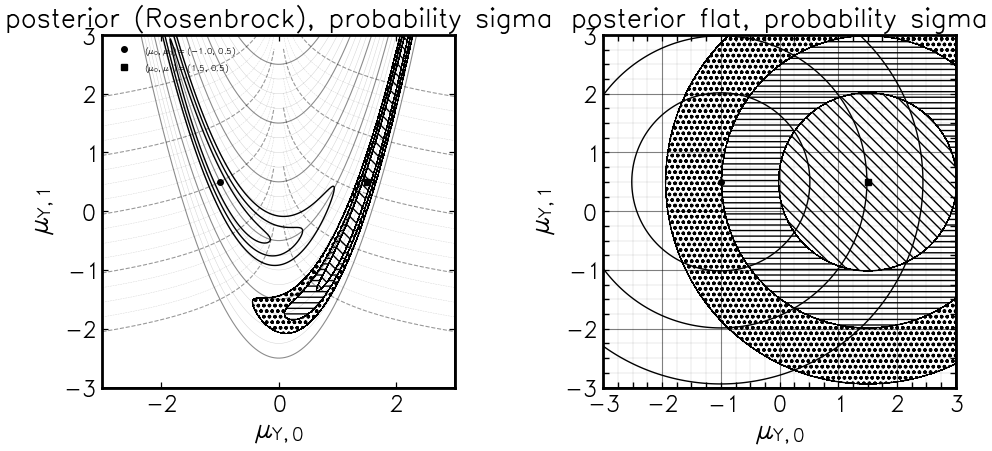

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([4.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# Two mean locations, used in both panels
muA = (-1.0, 0.5)
muB = ( 1.5, 0.5)

# Choose sigma convention:
# "radius"      -> exp(-k^2/2)
# "probability" -> 2D enclosed-probability convention
sigma_mode = "probability"

# ----------------------------
# Helpers for sigma contour levels
# ----------------------------
def sigma_ratios(mode="radius"):
    if mode == "radius":
        # 1σ, 2σ, 3σ in Mahalanobis-radius sense
        return np.exp(-0.5 * np.array([3, 2, 1])**2)   # ascending order
    elif mode == "probability":
        # 1σ, 2σ, 3σ in 2D enclosed-probability sense
        return np.array([0.0027, 0.0455, 0.3173])      # ascending order
    else:
        raise ValueError("mode must be 'radius' or 'probability'")

def sigma_levels(Z, mode="radius"):
    return Z.max() * sigma_ratios(mode)

def sigma_fill_edges(Z, mode="radius"):
    levels = sigma_levels(Z, mode)
    # 4 filled regions: outside 3σ, 3σ-2σ, 2σ-1σ, inside 1σ
    return np.array([0.0, levels[0], levels[1], levels[2], Z.max() * 1.000001])

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.0,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):
    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transformed coordinate
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )
    return np.exp(logp)

Z1A = post(X, Y, mu0=muA[0], mu1=muA[1])
Z1B = post(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat,
              n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2A = post_flat(X, Y, mu0=muA[0], mu1=muA[1])
Z2B = post_flat(X, Y, mu0=muB[0], mu1=muB[1])

# ----------------------------
# Figure
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)

# 4 hatch bands: outside 3σ, 3σ-2σ, 2σ-1σ, inside 1σ
hatches_A = ['', '...', '///', 'xxx']
hatches_B = ['', 'ooo', '---', '\\\\\\']

# ----------------------------
# Left panel: two Rosenbrock posteriors + transformed coordinate grid
# ----------------------------
ax = axes[0]
ax.set_facecolor('white')

fill_A_left = sigma_fill_edges(Z1A, sigma_mode)
fill_B_left = sigma_fill_edges(Z1B, sigma_mode)
line_A_left = sigma_levels(Z1A, sigma_mode)
line_B_left = sigma_levels(Z1B, sigma_mode)

cf_left_A = ax.contourf(
    X, Y, Z1A,
    levels=fill_A_left,
    colors=['white'] * (len(fill_A_left) - 1),
    hatches=hatches_A
)
for coll in cf_left_A.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

cf_left_B = ax.contourf(
    X, Y, Z1B,
    levels=fill_B_left,
    colors=['white'] * (len(fill_B_left) - 1),
    hatches=hatches_B
)
for coll in cf_left_B.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

# 1σ, 2σ, 3σ contour lines
ax.contour(
    X, Y, Z1A,
    levels=line_A_left,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z1B,
    levels=line_B_left,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)

# transformed coordinate family: nu1 = nu0^2 + c
# orthogonal family: nu1 = -0.5 log|nu0| + C
nu0_line = np.linspace(-3, 3, 1200)
c_values = np.arange(-2.5, 2.51, 0.25)

for i, c in enumerate(c_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.45 if is_major else 0.18

    nu1_line = nu0_line**2 + c
    mask = (nu1_line >= -3) & (nu1_line <= 3)
    ax.plot(nu0_line[mask], nu1_line[mask], color='black', lw=lw, alpha=alpha)

nu0_pos = np.linspace(0.08, 3.0, 1200)
nu0_neg = np.linspace(-3.0, -0.08, 1200)
C_values = np.arange(-1.5, 2.51, 0.25)

for i, C in enumerate(C_values):
    is_major = (i % 4 == 0)
    lw = 0.80 if is_major else 0.35
    alpha = 0.40 if is_major else 0.16

    nu1_pos = -0.5 * np.log(np.abs(nu0_pos)) + C
    nu1_neg = -0.5 * np.log(np.abs(nu0_neg)) + C

    mask_pos = (nu1_pos >= -3) & (nu1_pos <= 3)
    mask_neg = (nu1_neg >= -3) & (nu1_neg <= 3)

    ax.plot(nu0_pos[mask_pos], nu1_pos[mask_pos], color='black', lw=lw, alpha=alpha, ls='--')
    ax.plot(nu0_neg[mask_neg], nu1_neg[mask_neg], color='black', lw=lw, alpha=alpha, ls='--')

ax.plot(muA[0], muA[1], 'o', color='black', ms=4, label=rf'$(\mu_0,\mu_1)=({muA[0]},\,{muA[1]})$')
ax.plot(muB[0], muB[1], 's', color='black', ms=4, label=rf'$(\mu_0,\mu_1)=({muB[0]},\,{muB[1]})$')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title(f'posterior (Rosenbrock), {sigma_mode} sigma')
ax.legend(frameon=False, fontsize=8, loc='upper left')

# ----------------------------
# Right panel: two flat posteriors at same mean values + ordinary grid
# ----------------------------
ax = axes[1]
ax.set_facecolor('white')

fill_A_right = sigma_fill_edges(Z2A, sigma_mode)
fill_B_right = sigma_fill_edges(Z2B, sigma_mode)
line_A_right = sigma_levels(Z2A, sigma_mode)
line_B_right = sigma_levels(Z2B, sigma_mode)

cf_right_A = ax.contourf(
    X, Y, Z2A,
    levels=fill_A_right,
    colors=['white'] * (len(fill_A_right) - 1),
    hatches=hatches_A
)
for coll in cf_right_A.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

cf_right_B = ax.contourf(
    X, Y, Z2B,
    levels=fill_B_right,
    colors=['white'] * (len(fill_B_right) - 1),
    hatches=hatches_B
)
for coll in cf_right_B.collections:
    coll.set_edgecolor('black')
    coll.set_linewidth(0.35)
    coll.set_facecolor('white')

# 1σ, 2σ, 3σ contour lines
ax.contour(
    X, Y, Z2A,
    levels=line_A_right,
    colors='black',
    linewidths=1.0,
    linestyles='solid'
)
ax.contour(
    X, Y, Z2B,
    levels=line_B_right,
    colors='black',
    linewidths=1.0,
    linestyles='dashed'
)

ax.set_xticks(np.arange(-3, 3.1, 1.0))
ax.set_yticks(np.arange(-3, 3.1, 1.0))
ax.set_xticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.set_yticks(np.arange(-3, 3.1, 0.25), minor=True)
ax.grid(which='major', color='black', linewidth=0.8, alpha=0.5)
ax.grid(which='minor', color='black', linewidth=0.3, alpha=0.2)

ax.plot(muA[0], muA[1], 'o', color='black', ms=4)
ax.plot(muB[0], muB[1], 's', color='black', ms=4)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_xlabel(r'$\mu_{Y,0}$')
ax.set_ylabel(r'$\mu_{Y,1}$')
ax.set_title(f'posterior flat, {sigma_mode} sigma')

plt.show()

Font 'rm' does not have a glyph for '\\mid' [U+2223], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\mid' [U+2223], substituting with a dummy symbol.


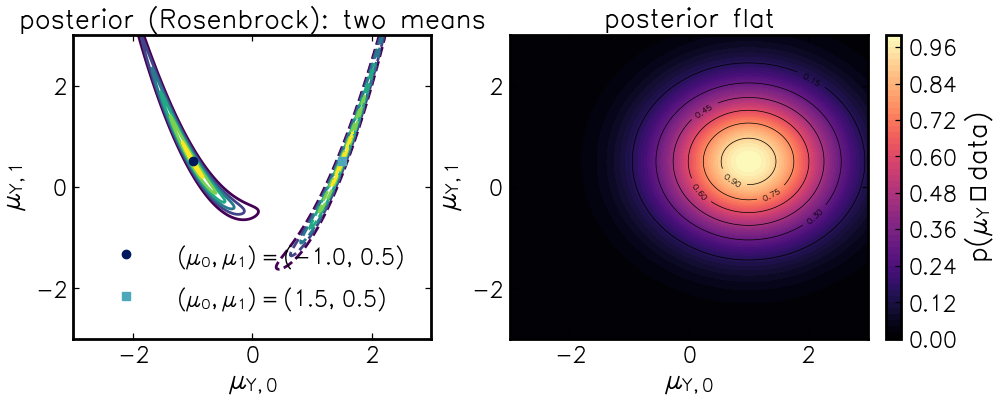

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Shared grid
# ----------------------------
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

n_d = 50
sigmas_rosen = np.array([4.0, 1.0])
sigmas_flat = np.array([1.0, 1.0])

# ----------------------------
# Rosenbrock-like posterior
# ----------------------------
def post(nu0, nu1,
         mu0=1.0,
         mu1=0.5,
         sigmas=sigmas_rosen,
         n_d=n_d):

    sig = (sigmas / np.sqrt(n_d))**2

    nu_target0 = mu0
    nu_target1 = -mu0**2 + mu1

    # transform so density is computed in degenerate space
    nu1_trans = nu1 - nu0**2

    logp = -0.5 * (
        (nu0 - nu_target0)**2 / sig[0]
        + (nu1_trans - nu_target1)**2 / sig[1]
    )

    return np.exp(logp)

# Two different means for the first panel
Z1_a = post(X, Y, mu0=-1.0, mu1=0.5)
Z1_b = post(X, Y, mu0= 1.5, mu1=0.5)

# ----------------------------
# Flat posterior
# ----------------------------
def post_flat(nu0, nu1,
              mu0=1.0,
              mu1=0.5,
              sigmas=sigmas_flat, n_d=n_d):
    sigma = 1.0
    logp = -0.5 * (((nu0 - mu0)**2 / sigma) + ((nu1 - mu1)**2 / sigma))
    return np.exp(logp)

Z2 = post_flat(X, Y)

# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# Left panel: two Rosenbrock densities at different means
levels_a = np.linspace(Z1_a.max() * 0.15, Z1_a.max() * 0.95, 6)
levels_b = np.linspace(Z1_b.max() * 0.15, Z1_b.max() * 0.95, 6)

cs1 = axes[0].contour(X, Y, Z1_a, levels=levels_a, linewidths=2)
cs2 = axes[0].contour(X, Y, Z1_b, levels=levels_b, linewidths=2, linestyles='--')

axes[0].plot(-1.0, 0.5, 'o', ms=6, label=r'$(\mu_0,\mu_1)=(-1.0,\,0.5)$')
axes[0].plot( 1.5, 0.5, 's', ms=6, label=r'$(\mu_0,\mu_1)=(1.5,\,0.5)$')

axes[0].set_xlabel(r'$\mu_{Y,0}$')
axes[0].set_ylabel(r'$\mu_{Y,1}$')
axes[0].set_title('posterior (Rosenbrock): two means')
axes[0].legend(frameon=False, loc='lower left')

# Right panel: flat posterior
cf = axes[1].contourf(X, Y, Z2, levels=60, cmap='magma')
lines = axes[1].contour(X, Y, Z2, levels=8, colors='black', linewidths=0.5)
axes[1].clabel(lines, inline=True, fontsize=8)

axes[1].set_xlabel(r'$\mu_{Y,0}$')
axes[1].set_ylabel(r'$\mu_{Y,1}$')
axes[1].set_title('posterior flat')

cbar = fig.colorbar(cf, ax=axes[1])
cbar.set_label(r'$p(\mu_Y \mid \rm data)$')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


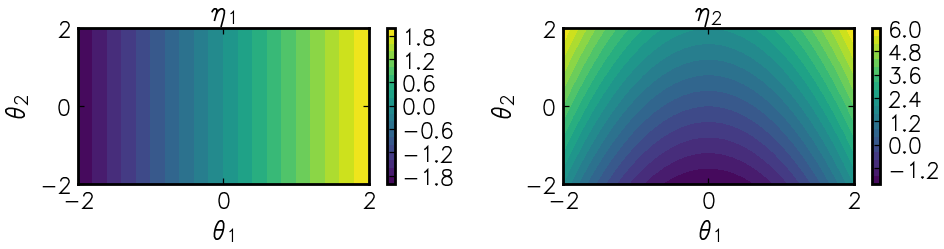

In [22]:
num = 30

MIN_MU = -2
MAX_MU = 2

xs = jnp.linspace(MIN_MU, MAX_MU, num) # MEAN
ys = jnp.linspace(MIN_MU, MAX_MU, num) # VARIANCE
xs,ys = jnp.meshgrid(xs, ys)

X = jnp.stack([xs.flatten(), (ys.flatten())], axis=-1)
etas = jax.vmap(mu_y_from_x)(X) #model.apply(w, X)


# MAKE NICE PICTURE
plt.figure(figsize=(10, 3))

plt.subplot(121)

data = etas[:, 0].reshape(xs.shape)

im = plt.contourf(xs, ys, (data), cmap='viridis', levels=20)
plt.colorbar(im)
#plt.yscale('log')
plt.ylabel(r'$\theta_2$')
plt.xlabel(r'$\theta_1$')
plt.title(r'$ \eta_1$')
plt.legend(framealpha=0., loc='lower left')

plt.subplot(122)
data = etas[:, 1].reshape(xs.shape)

im = plt.contourf(xs, ys, (data), cmap='viridis', levels=20)
plt.colorbar(im)
#plt.yscale('log')
plt.ylabel(r'$\theta_2$')
plt.xlabel(r'$\theta_1$')
plt.title(r'$\eta_2$')
plt.legend(framealpha=0., loc='lower left')
plt.tight_layout()